In [1]:
import pandas as pd

# File path to your dataset
data=pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\RoadAccidentCurrent.xlsx")

# Show dataset information
print(data.info())

# Display the first few rows
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60498 entries, 0 to 60497
Data columns (total 65 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Accident_Index                               60498 non-null  int64  
 1   longitude                                    60498 non-null  float64
 2   latitude                                     60498 non-null  float64
 3   Police_Force                                 60498 non-null  int64  
 4   Accident_Severity                            60498 non-null  int64  
 5   Number_of_Vehicles                           60498 non-null  int64  
 6   Number_of_Casualties                         60498 non-null  int64  
 7   Day_of_Week                                  60498 non-null  int64  
 8   Time                                         60497 non-null  object 
 9   Local_Authority_(District)                   60498 non-null  object 
 10

In [2]:
print(data.isnull().sum())

Accident_Index           0
longitude                0
latitude                 0
Police_Force             0
Accident_Severity        0
                        ..
Engine_Capacity_(CC)     0
Propulsion_Code          0
Age_of_Vehicle           0
Driver_IMD_Decile        0
Driver_Home_Area_Type    0
Length: 65, dtype: int64


In [3]:
print(data.select_dtypes(include=['object']).columns)

Index(['Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)',
       'LSOA_of_Accident_Location', 'Date'],
      dtype='object')


In [8]:
# Convert all categorical columns to string type
categorical_columns = ['Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)', 
                       'LSOA_of_Accident_Location', 'Date']

# Ensure all categorical columns are strings and fill missing values
data[categorical_columns] = data[categorical_columns].astype(str).fillna("Unknown")

# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder

label_encoders = {}  # Dictionary to store encoders
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])  # Encode categorical features
    label_encoders[col] = le  # Store the encoder

# Verify the encoding
print(data.head())  # Check if categorical columns are now numeric

   Accident_Index  longitude   latitude  Police_Force  Accident_Severity  \
0               1  78.610393  14.724026             1                  2   
1               2  78.534042  14.762353             1                  3   
2               3  78.470877  14.745606             1                  3   
3               4  78.557994  14.667128             1                  3   
4               5  78.576431  14.703443             1                  3   

   Number_of_Vehicles  Number_of_Casualties  Day_of_Week  Time  \
0                   1                     1            3   711   
1                   1                     1            4   701   
2                   2                     1            5  1754   
3                   1                     1            6    30   
4                   1                     1            2   813   

   Local_Authority_(District)  ...  Was_Vehicle_Left_Hand_Drive?  \
0                          13  ...                             1   
1         

In [10]:
# Drop irrelevant columns (modify based on your dataset)
features = data.drop(columns=["Accident_Index", "Date", "Time", "LSOA_of_Accident_Location", 
                              "Local_Authority_(District)", "Local_Authority_(Highway)", 
                              "Accident_Severity"])  # Keep only meaningful features

# Set the target column for classification
target = data["Accident_Severity"]

# Check dataset shape
print(f"Features shape: {features.shape}, Target shape: {target.shape}")

# Display first few rows of features
print(features.head())

Features shape: (60498, 58), Target shape: (60498,)
   longitude   latitude  Police_Force  Number_of_Vehicles  \
0  78.610393  14.724026             1                   1   
1  78.534042  14.762353             1                   1   
2  78.470877  14.745606             1                   2   
3  78.557994  14.667128             1                   1   
4  78.576431  14.703443             1                   1   

   Number_of_Casualties  Day_of_Week  1st_Road_Class  1st_Road_Number  \
0                     1            3               3             3218   
1                     1            4               4              450   
2                     1            5               5                0   
3                     1            6               3             3220   
4                     1            2               6                0   

   Road_Type  Speed_limit  ...  Was_Vehicle_Left_Hand_Drive?  \
0          6           30  ...                             1   
1          3  

In [11]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical features into numbers
le = LabelEncoder()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = le.fit_transform(features[col])

# Display first few rows after encoding
print(features.head())

   longitude   latitude  Police_Force  Number_of_Vehicles  \
0  78.610393  14.724026             1                   1   
1  78.534042  14.762353             1                   1   
2  78.470877  14.745606             1                   2   
3  78.557994  14.667128             1                   1   
4  78.576431  14.703443             1                   1   

   Number_of_Casualties  Day_of_Week  1st_Road_Class  1st_Road_Number  \
0                     1            3               3             3218   
1                     1            4               4              450   
2                     1            5               5                0   
3                     1            6               3             3220   
4                     1            2               6                0   

   Road_Type  Speed_limit  ...  Was_Vehicle_Left_Hand_Drive?  \
0          6           30  ...                             1   
1          3           30  ...                             1   
2 

In [12]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = features  # All processed features
y = target     # Target column (Accident Severity or any chosen attribute)

# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display shapes of training and testing sets
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (42348, 58)
Testing Set Shape: (18150, 58)


In [13]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier (C4.5 Approach)
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Train the model
clf.fit(X_train, y_train)

print("Model Training Completed Successfully! 🎯")

Model Training Completed Successfully! 🎯


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions using the test set
y_pred = clf.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Display results
print(f"✅ Model Accuracy: {accuracy:.4f}")
print(f"✅ Model Precision: {precision:.4f}")
print(f"✅ Model Recall: {recall:.4f}")
print(f"✅ Model F1 Score: {f1:.4f}")

✅ Model Accuracy: 0.8636
✅ Model Precision: 0.7929
✅ Model Recall: 0.8636
✅ Model F1 Score: 0.8028


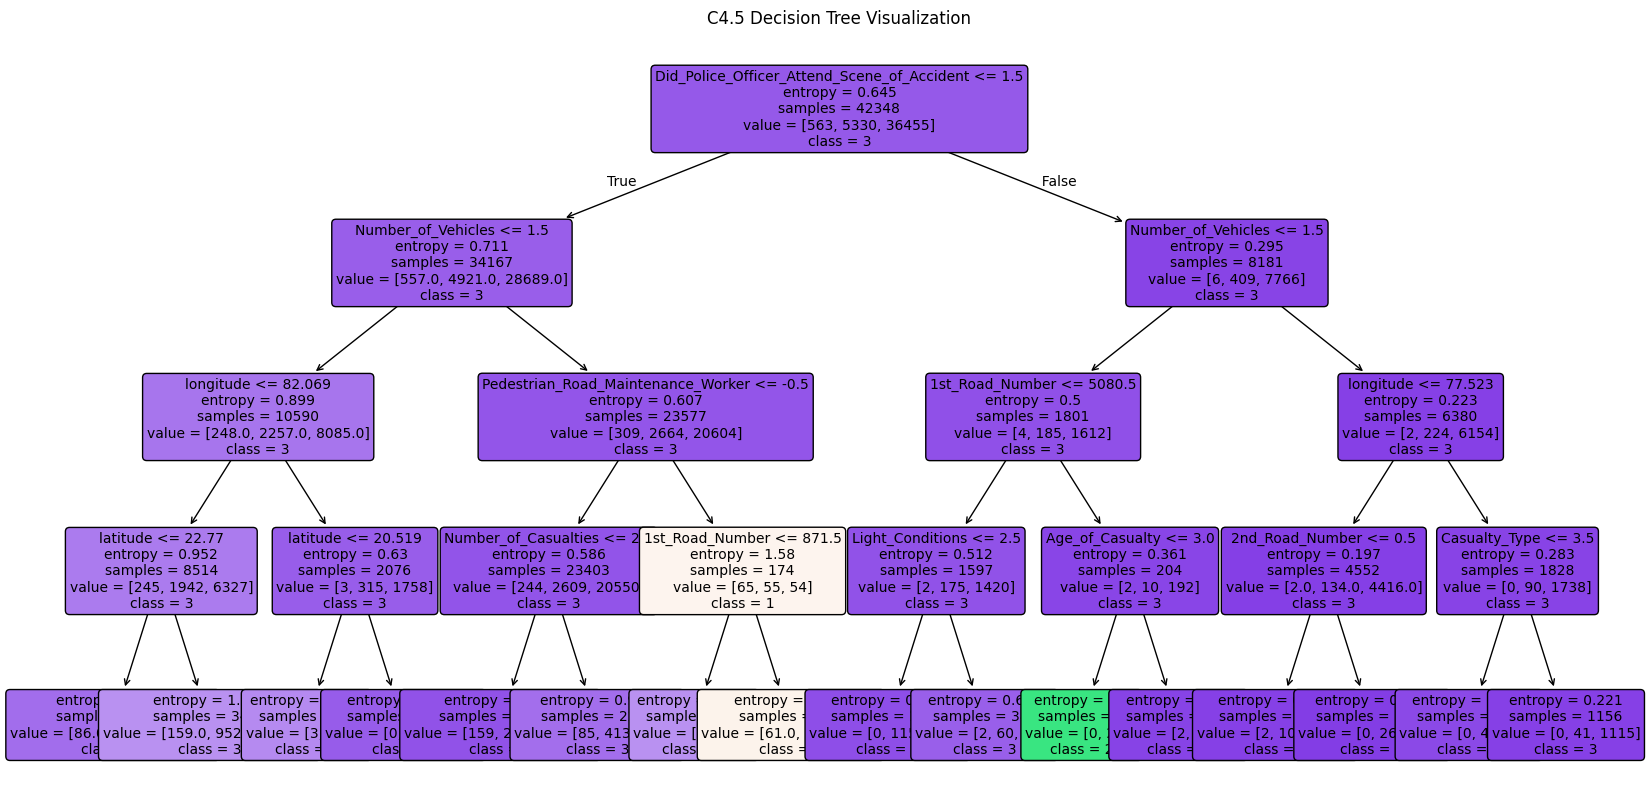

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set the figure size
plt.figure(figsize=(20, 10))

# Convert class names to strings
class_names = [str(c) for c in clf.classes_]

# Plot the decision tree
plot_tree(clf, feature_names=X.columns, class_names=class_names, filled=True, rounded=True, fontsize=10)

# Set the title
plt.title("C4.5 Decision Tree Visualization")

# Show the tree
plt.show()

In [22]:
import joblib

# Save the trained C4.5 decision tree model
joblib.dump(clf, "decision_tree_c4.5.pkl")

print("Model saved successfully!")

Model saved successfully!
